In [19]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg
from thesis_project.training.key_word_spotting import CrossEntropyPlusRankLoss, fit_dynamic_model, validate_dynamic_model

In [20]:
maximum_useful_rank = 64
target_rank = 16
target_rank_normalized = (target_rank - 1) / (maximum_useful_rank - 1)
batch_size = 64

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [21]:
# Model
base_model = KWSBase(cfg).to(device)
router = GRURouter(
    input_dim=base_model.spectrogram_bins, #type: ignore
    fc_hidden_dim=128,
    gru_hidden_dim=64,
    num_gru_layers=1,
    max_rank=maximum_useful_rank,
    last_layer_bias_init= 4.0 # to bias towards full rank at start
    ).to(device)

model = KWSDynamic(base=base_model, router=router).to(device)
model_path = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2025-12-15_11-05-35/best_model.pth"
ckpt = torch.load(model_path, map_location=device)

model.load_state_dict(ckpt["model_state"])
model.to(device)

KWSDynamic(
  (base): KWSBase(
    (spectrogram): SpectrogramBlock(
      (spec): Spectrogram()
      (db): AmplitudeToDB()
      (inv): InverseSpectrogram()
    )
    (frontend): LowRankPointwiseConv1d()
    (backbone): ModuleList(
      (0-2): 3 x ModuleList(
        (0): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
          (act1): PReLU(num_parameters=1)
          (dropout1): Dropout(p=0.1, inplace=False)
          (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (ddw_conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), groups=128, bias=False)
          (chomp): Chomp()
          (act2): PReLU(num_parameters=1)
          (dropout2): Dropout(p=0.1, inplace=False)
          (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (pw_layer_2): LowRankPointwiseConv1d()
        )
        (1): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
      

In [22]:
# Loss function and optimizer
criterion = CrossEntropyPlusRankLoss(
    target_rank_normalized=target_rank_normalized,
    rank_loss_weight=1.0,
    rank_loss_mode="batch_mean_mse",
    rank_var_weight=0.1,
)
data_dir = get_data_dir()
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory = pin_memory, num_workers=num_workers)

Adding noise: 100%|██████████| 4515/4515 [00:11<00:00, 390.55sample/s]


In [28]:
# validation
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]
validation_results=validate_dynamic_model(
    model=model,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    snr_values=VAL_SNR_VALUES,
)


SNR=-5: loss=0.7119, acc=79.62%, mean_rnorm=0.5294, exp_rank=34.35


SNR=0: loss=0.4398, acc=86.84%, mean_rnorm=0.4428, exp_rank=28.90


SNR=5: loss=0.3309, acc=90.61%, mean_rnorm=0.3971, exp_rank=26.01


SNR=10: loss=0.2822, acc=92.20%, mean_rnorm=0.3865, exp_rank=25.35


SNR=15: loss=0.2600, acc=93.20%, mean_rnorm=0.3845, exp_rank=25.23


SNR=inf: loss=0.2345, acc=94.17%, mean_rnorm=0.3836, exp_rank=25.17


In [29]:
import math
import matplotlib.pyplot as plt


def plot_snr_acc_rank(
    results: dict,
    *,
    title: str = "Validation: Accuracy and Rank vs SNR",
):
    """
    results: dict like:
      results[snr] = {
        "loss": ...,
        "acc": ... (percent),
        "mean_rank_normalized": ...,
        "expected_rank": ...
      }
    """

    # --- sort SNRs nicely ---
    def snr_sort_key(s):
        if s is None:
            return (2, 0.0)
        if isinstance(s, float) and math.isinf(s):
            return (1, 1e9)
        return (0, float(s))

    snrs = sorted(results.keys(), key=snr_sort_key)

    x, x_labels, acc, exp_rank = [], [], [], []

    for s in snrs:
        d = results[s]
        if s is None:
            x.append(float("inf"))
            x_labels.append("None")
        elif isinstance(s, float) and math.isinf(s):
            x.append(s)
            x_labels.append("inf")
        else:
            x.append(float(s))
            x_labels.append(str(s))

        acc.append(float(d["acc"]))
        exp_rank.append(float(d["expected_rank"]))

    # Replace inf for plotting
    finite_x = [v for v in x if math.isfinite(v)]
    if not finite_x:
        raise ValueError("No finite SNR values to plot.")
    inf_x_pos = max(finite_x) + 5.0
    x_plot = [inf_x_pos if not math.isfinite(v) else v for v in x]

    # --- colors ---
    acc_color = "tab:blue"
    rank_color = "tab:orange"

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(8.5, 4.8))

    # Accuracy curve
    l1 = ax1.plot(
        x_plot,
        acc,
        marker="o",
        linewidth=2.5,
        color=acc_color,
        label="Accuracy",
    )
    ax1.set_xlabel("SNR (dB)")
    ax1.set_ylabel("Accuracy (%)", color=acc_color)
    ax1.tick_params(axis="y", colors=acc_color)
    ax1.grid(True, which="both", alpha=0.3)

    # Rank curve
    ax2 = ax1.twinx()
    l2 = ax2.plot(
        x_plot,
        exp_rank,
        marker="s",
        linewidth=2.5,
        linestyle="--",
        color=rank_color,
        label="Expected Rank",
    )
    ax2.set_ylabel("Expected Rank", color=rank_color)
    ax2.tick_params(axis="y", colors=rank_color)

    # X ticks
    ax1.set_xticks(x_plot)
    ax1.set_xticklabels(x_labels)

    # Combined legend
    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.set_title(title)
    plt.tight_layout()
    plt.show()


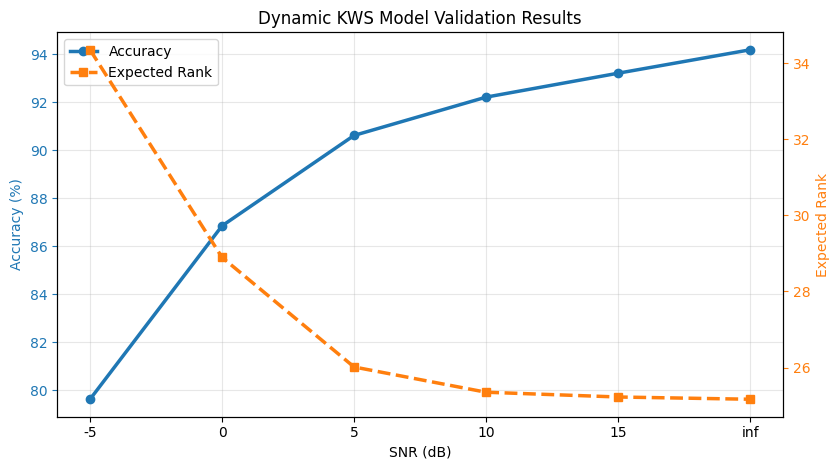

In [30]:
# Plot validation results
plot_snr_acc_rank(validation_results, title="Dynamic KWS Model Validation Results")